# Fairness and Subgroup Analysis — deployed V8 model

**What this audits.** The V8 configuration actually served by the prototype: the
sixty-seven features chosen by recursive feature elimination, less a target encoding of
race, leaving **sixty-six**. The manuscript's Section 8.13 is generated from this notebook.

**Why race is still reported.** V8 does not use race as a predictor, but not using an
attribute is no guarantee of performing equally across it. The audit therefore reports
per-subgroup discrimination, calibration and operating-point behaviour across age, sex and
race, and closes with the ablation that justified removing the race encoding.

Sections:
1. Retrain V8 on the paper's patient-grouped split
2. Subgroup definitions
3. Per-subgroup metrics with bootstrap 95% CIs
4. Figure — discrimination parity (the manuscript's Figure 17)
5. The Section 9.1 equity concern, measured directly
6. Race ablation — does the race encoding do any work?
7. Save results and notes for the manuscript

---

## §1. Retrain the deployed V8 model on the paper's split

In [1]:
import os
N_JOBS = 8
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = str(N_JOBS)

import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, joblib, xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix
warnings.filterwarnings("ignore")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "savefig.dpi": 150})

REPO = Path.cwd().resolve()
while REPO.name != "medicare-30day-readmission-mimic-iv" and REPO.parent != REPO:
    REPO = REPO.parent
PUB, RESULTS, FIGS = REPO.parent, REPO / "results", REPO / "figures"
DATA = PUB / "Dataset" / "mimic-parquet"
API_ART = PUB / "readmission-api" / "artifacts"
SEED = 42
rng = np.random.RandomState(SEED)

V7 = pd.read_parquet(PUB / "training_table_v7.parquet")
V10 = pd.read_parquet(PUB / "training_table_v10.parquet")
v7u = [c for c in V7.columns if c not in V10.columns]
DF = pd.concat([V10.reset_index(drop=True), V7[v7u].reset_index(drop=True)], axis=1)

serving = joblib.load(API_ART / "serving_artifacts.joblib")
FEATURES = list(serving["feature_order"])
assert "race_te" not in FEATURES, "V8 must not contain the race encoding"
print(f"deployed feature set: {len(FEATURES)} features, race excluded")

def encode(cols):
    X = DF[cols].copy()
    for c in serving["categorical_features"]:
        if c in cols:
            X[c] = X[c].astype(str).fillna("__NA__").map(serving["cat_maps"][c]).astype(float)
    return X.apply(pd.to_numeric, errors="coerce")

X = encode(FEATURES)
y = DF["readmit_30d"].to_numpy().astype(int)
split = np.load(RESULTS / "v7_split_indices.npz")
tr, te = split["train_idx"], split["test_idx"]

PARAMS = dict(n_estimators=600, learning_rate=0.05, max_depth=5, subsample=0.9,
              colsample_bytree=0.9, random_state=SEED, n_jobs=N_JOBS,
              eval_metric="auc", tree_method="hist")
clf = xgb.XGBClassifier(**PARAMS)
clf.fit(X.loc[tr].to_numpy(np.float32), y[tr])
p = clf.predict_proba(X.loc[te].to_numpy(np.float32))[:, 1]
yt = y[te]
OVERALL = roc_auc_score(yt, p)
THRESHOLD = float(json.loads((API_ART / "metadata.json").read_text())["metrics"]["operating_threshold"])
print(f"V8 overall test AUROC {OVERALL:.4f} on {len(yt):,} admissions, threshold {THRESHOLD:.4f}")

deployed feature set: 66 features, race excluded


V8 overall test AUROC 0.7947 on 49,191 admissions, threshold 0.2176


## §2. Subgroup definitions (age band, sex, race)

In [2]:
sub = DF.iloc[te].reset_index(drop=True)
race_raw = pd.read_parquet(DATA / "admissions.parquet", columns=["hadm_id", "race"])
sub = sub.merge(race_raw, on="hadm_id", how="left")

def age_band(a):
    if a < 65:  return "<65"
    if a < 75:  return "65-74"
    if a < 85:  return "75-84"
    return "85+"

def race_cat(r):
    r = str(r).upper()
    if "WHITE" in r: return "White"
    if "BLACK" in r: return "Black"
    if "HISPANIC" in r or "LATINO" in r: return "Hispanic/Latino"
    if "ASIAN" in r: return "Asian"
    return "Other/Unknown"

sub["age_band"] = sub["age_at_admit"].apply(age_band)
sub["sex"] = sub["gender"].astype(str).str.upper().map({"F": "Female", "M": "Male"}).fillna("Unknown")
sub["race_cat"] = sub["race"].apply(race_cat)
ORDER = {"age_band": ["<65", "65-74", "75-84", "85+"],
         "sex": ["Female", "Male"],
         "race_cat": ["White", "Black", "Hispanic/Latino", "Asian", "Other/Unknown"]}
for c in ORDER:
    print(c, "->", sub[c].value_counts().to_dict())

age_band -> {'65-74': 15099, '75-84': 14011, '<65': 10288, '85+': 9793}
sex -> {'Female': 25206, 'Male': 23985}
race_cat -> {'White': 36094, 'Black': 6860, 'Other/Unknown': 3054, 'Hispanic/Latino': 2038, 'Asian': 1145}


## §3. Per-subgroup metrics with bootstrap 95% CIs

Discrimination (AUROC), calibration (ECE and calibration-in-the-large), and
operating-point behaviour (sensitivity, false-positive rate) at the deployed threshold.

In [3]:
def auroc_ci(yy, pp, n_boot=1000):
    pt = roc_auc_score(yy, pp); n = len(yy); vals = []
    for _ in range(n_boot):
        ix = rng.randint(0, n, n)
        if len(np.unique(yy[ix])) < 2: continue
        vals.append(roc_auc_score(yy[ix], pp[ix]))
    return pt, float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def ece(yy, pp, nb=10):
    bins = np.linspace(0, 1, nb + 1); idx = np.digitize(pp, bins) - 1; e = 0.0
    for b in range(nb):
        m = idx == b
        if m.sum(): e += m.mean() * abs(pp[m].mean() - yy[m].mean())
    return float(e)

RESULTS_D = {"model": f"V8 ({len(FEATURES)} features, race excluded)",
             "overall_auroc": round(float(OVERALL), 6), "threshold": THRESHOLD}
for col, groups in ORDER.items():
    RESULTS_D[col] = {}
    rows = []
    for g in groups:
        m = (sub[col] == g).to_numpy()
        if m.sum() < 50 or len(np.unique(yt[m])) < 2: continue
        a, lo, hi = auroc_ci(yt[m], p[m])
        pred = (p[m] >= THRESHOLD).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt[m], pred, labels=[0, 1]).ravel()
        RESULTS_D[col][g] = {"n": int(m.sum()), "auroc": round(a, 4),
                             "ci": [round(lo, 4), round(hi, 4)], "ece": round(ece(yt[m], p[m]), 4),
                             "mean_predicted": round(float(p[m].mean()), 4),
                             "observed": round(float(yt[m].mean()), 4),
                             "sensitivity": round(float(tp/(tp+fn)) if (tp+fn) else np.nan, 3),
                             "fpr": round(float(fp/(fp+tn)) if (fp+tn) else np.nan, 3)}
        v = RESULTS_D[col][g]
        rows.append({col: g, "n": f"{v['n']:,}", "AUROC": f"{v['auroc']:.3f}",
                     "95% CI": f"[{v['ci'][0]:.3f},{v['ci'][1]:.3f}]", "ECE": f"{v['ece']:.3f}",
                     "pred/obs": f"{v['mean_predicted']:.3f}/{v['observed']:.3f}",
                     "Sens": f"{v['sensitivity']:.2f}", "FPR": f"{v['fpr']:.2f}"})
    print(f"\n===== {col.upper()} =====")
    print(pd.DataFrame(rows).to_string(index=False))


===== AGE_BAND =====
age_band      n AUROC        95% CI   ECE    pred/obs Sens  FPR
     <65 10,288 0.783 [0.773,0.793] 0.013 0.270/0.273 0.81 0.42
   65-74 15,099 0.800 [0.793,0.808] 0.009 0.212/0.210 0.76 0.32
   75-84 14,011 0.792 [0.783,0.801] 0.007 0.192/0.188 0.71 0.29
     85+  9,793 0.786 [0.775,0.797] 0.011 0.174/0.170 0.68 0.27



===== SEX =====
   sex      n AUROC        95% CI   ECE    pred/obs Sens  FPR
Female 25,206 0.797 [0.790,0.804] 0.008 0.201/0.195 0.73 0.30
  Male 23,985 0.791 [0.785,0.798] 0.008 0.222/0.224 0.77 0.34



===== RACE_CAT =====
       race_cat      n AUROC        95% CI   ECE    pred/obs Sens  FPR
          White 36,094 0.793 [0.787,0.798] 0.006 0.206/0.207 0.74 0.31
          Black  6,860 0.758 [0.746,0.771] 0.009 0.235/0.230 0.76 0.39
Hispanic/Latino  2,038 0.809 [0.791,0.829] 0.025 0.261/0.268 0.82 0.38
          Asian  1,145 0.829 [0.801,0.855] 0.040 0.233/0.231 0.84 0.31
  Other/Unknown  3,054 0.860 [0.843,0.876] 0.029 0.165/0.140 0.79 0.24


## §4. Figure — discrimination parity (manuscript Figure 17)

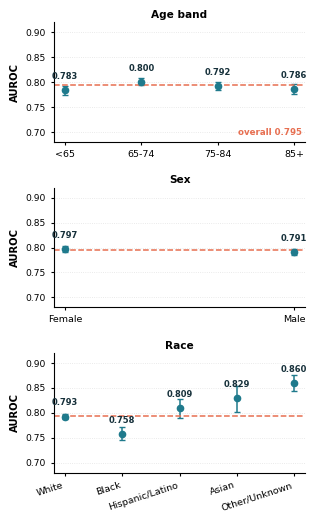

Saved figures/fairness_auroc.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(3.30, 5.35))
TITLES = {"age_band": "Age band", "sex": "Sex", "race_cat": "Race"}
for ax, col in zip(axes, ["age_band", "sex", "race_cat"]):
    gs = list(RESULTS_D[col].keys()); xs = np.arange(len(gs))
    pts = [RESULTS_D[col][g]["auroc"] for g in gs]
    lo = [pts[i] - RESULTS_D[col][g]["ci"][0] for i, g in enumerate(gs)]
    hi = [RESULTS_D[col][g]["ci"][1] - pts[i] for i, g in enumerate(gs)]
    ax.errorbar(xs, pts, yerr=[lo, hi], fmt="o", color="#1F7A8C", capsize=2.5,
                markersize=4.5, lw=1.4, elinewidth=1.1)
    ax.axhline(OVERALL, color="#E76F51", ls="--", lw=1.1)
    ax.set_xticks(xs)
    ax.set_xticklabels(gs, fontsize=6.8, rotation=18 if col == "race_cat" else 0,
                       ha="right" if col == "race_cat" else "center")
    ax.set_ylim(0.68, 0.92); ax.set_yticks([0.70, 0.75, 0.80, 0.85, 0.90])
    ax.tick_params(axis="y", labelsize=6.6); ax.tick_params(length=2)
    ax.set_ylabel("AUROC", fontsize=7.2, fontweight="bold")
    ax.set_title(TITLES[col], fontsize=7.6, fontweight="bold", pad=3)
    ax.grid(True, axis="y", ls=":", alpha=0.35, linewidth=0.6); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for i, g in enumerate(gs):
        ax.annotate(f"{pts[i]:.3f}", (i, pts[i]), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=6.0, fontweight="bold", color="#16303A")
axes[0].annotate(f"overall {OVERALL:.3f}", xy=(0.985, 0.06), xycoords="axes fraction",
                 ha="right", fontsize=6.2, fontweight="bold", color="#E76F51")
fig.tight_layout(h_pad=1.1)
fig.savefig(FIGS / "fairness_auroc.png", bbox_inches="tight", pad_inches=0.03, dpi=400)
plt.show()
print("Saved figures/fairness_auroc.png")

## §5. The Section 9.1 equity concern, measured directly

Section 9.1 worries that patients with heavy prior utilization, who are disproportionately
socially disadvantaged, are assigned higher risk. The question is whether that risk is
**earned** (calibrated) or **inflated** (systematic over-prediction).

In [5]:
sub["prior_util"] = pd.cut(sub["prior_admissions_6m"].fillna(0),
                           bins=[-0.1, 0, 1, 3, 1e9], labels=["0", "1", "2-3", "4+"])
rows = []
for g in ["0", "1", "2-3", "4+"]:
    m = (sub["prior_util"] == g).to_numpy()
    if m.sum() == 0: continue
    rows.append({"Prior admits (6mo)": g, "n": f"{int(m.sum()):,}",
                 "Mean predicted": f"{p[m].mean():.3f}", "Observed": f"{yt[m].mean():.3f}",
                 "pred - obs": f"{p[m].mean() - yt[m].mean():+.3f}"})
RESULTS_D["prior_utilization_calibration"] = rows
print(pd.DataFrame(rows).to_string(index=False))
print("\nIf 'pred - obs' sits near zero at every level, the higher risk assigned to")
print("high-utilization patients is calibrated (earned) rather than inflated bias.")

Prior admits (6mo)      n Mean predicted Observed pred - obs
                 0 29,176          0.152    0.150     +0.002
                 1 10,316          0.224    0.218     +0.006
               2-3  6,727          0.317    0.317     +0.000
                4+  2,972          0.502    0.513     -0.010

If 'pred - obs' sits near zero at every level, the higher risk assigned to
high-utilization patients is calibrated (earned) rather than inflated bias.


## §6. Race ablation — does the race encoding do any work?

The RFE-selected set contained `race_te`, a target encoding whose predictive value comes
from an observed difference in outcome rates rather than a clinical mechanism. Rather than
argue about it, retrain with and without on the identical split.

In [6]:
RFE67 = json.loads((RESULTS / "rfe_selection_results.json").read_text())["rfe_selected"]
assert "race_te" in RFE67 and len(RFE67) == 67

# Use the race_te column the paper's pipeline already produced (out-of-fold target
# encoding). Rebuilding it here with a plain train mean would be a different feature
# and would not reproduce the manuscript's ablation.
assert "race_te" in DF.columns, "race_te should come from the engineered tables"

X67 = encode(RFE67)
clf67 = xgb.XGBClassifier(**PARAMS)
clf67.fit(X67.loc[tr].to_numpy(np.float32), y[tr])
p67 = clf67.predict_proba(X67.loc[te].to_numpy(np.float32))[:, 1]
a67 = roc_auc_score(yt, p67)

diffs = []
for _ in range(2000):
    ix = rng.randint(0, len(yt), len(yt))
    if len(np.unique(yt[ix])) < 2: continue
    diffs.append(roc_auc_score(yt[ix], p67[ix]) - roc_auc_score(yt[ix], p[ix]))
diffs = np.array(diffs)
lo_d, hi_d = np.percentile(diffs, [2.5, 97.5])
pval = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())

wm = (sub["race_cat"] == "White").to_numpy(); bm = (sub["race_cat"] == "Black").to_numpy()
gap_with = roc_auc_score(yt[wm], p67[wm]) - roc_auc_score(yt[bm], p67[bm])
gap_without = roc_auc_score(yt[wm], p[wm]) - roc_auc_score(yt[bm], p[bm])

RESULTS_D["race_ablation"] = {
    "auroc_with_race": round(float(a67), 6), "auroc_without_race": round(float(OVERALL), 6),
    "difference": round(float(a67 - OVERALL), 6),
    "difference_ci95": [round(float(lo_d), 6), round(float(hi_d), 6)],
    "p_value": round(float(pval), 4),
    "white_minus_black_gap_with": round(float(gap_with), 4),
    "white_minus_black_gap_without": round(float(gap_without), 4)}
print(f"WITH race_te    (67 feat): {a67:.4f}")
print(f"WITHOUT race_te (66 feat): {OVERALL:.4f}")
print(f"difference {a67 - OVERALL:+.4f}  (95% CI {lo_d:+.4f} to {hi_d:+.4f}, p = {pval:.3f})")
print(f"White-minus-Black gap: {gap_with:+.4f} with  ->  {gap_without:+.4f} without")
print("\nThe encoding buys no discrimination and does not explain the gap, so it is")
print("excluded from the deployed model; the gap is a property of the other predictors.")

WITH race_te    (67 feat): 0.7946
WITHOUT race_te (66 feat): 0.7947
difference -0.0001  (95% CI -0.0010 to +0.0008, p = 0.748)
White-minus-Black gap: +0.0328 with  ->  +0.0346 without

The encoding buys no discrimination and does not explain the gap, so it is
excluded from the deployed model; the gap is a property of the other predictors.


## §7. Save results

In [7]:
(RESULTS / "fairness_v8.json").write_text(json.dumps(RESULTS_D, indent=2))
print("Saved results/fairness_v8.json")

Saved results/fairness_v8.json


## §8. Notes for the manuscript

- Section 8.13 reports these numbers: discrimination stable across age (0.783–0.800) and sex
  (0.797 / 0.791), lowest for Black patients (0.758, CI 0.746–0.771) against White patients
  (0.793, CI 0.787–0.798), with non-overlapping intervals.
- Calibration is good within every stratum, so the disparity is one of **rank-ordering**, not
  systematic over- or under-prediction. Equal calibration does not discharge the concern.
- The race ablation belongs in the same section: the encoding contributed nothing and did not
  account for the gap, so it was removed and the deployed model does not condition on race.
- State plainly that reporting performance by race for a model that does not use race is
  deliberate — not using an attribute is no guarantee of performing equally across it.
- Limitations: race is self-reported and collapsed into broad categories; small subgroups
  (Asian, <65) carry wider intervals; MIMIC-IV is single-center.
- This satisfies TRIPOD+AI item 13c (fairness).